# Linear Regression: Review

> 📖 Book: [ch03](../../.claude/skills/ml-knowledge/chapters/ch03-least-squares-pseudoinverse-tikhonov.md), [ch04](../../.claude/skills/ml-knowledge/chapters/ch04-linear-regression-gradient-descent.md) · Prev: [07](07_polynomial_regression.ipynb) · Next: [02_logistic_regression](../02_logistic_regression/01_hypothesis_and_activations.ipynb)

We have the following options to compute a linear regression:

1. **Solve the least-squares problem** $\min_\theta \frac12\|X\theta - y\|^2$, which leads to the normal equations

    $$
    X^TX\theta = X^Ty .
    $$

    If $X^TX$ is invertible,

    $$
    \theta = (X^TX)^{-1}X^Ty .
    $$

    In practice $X^TX$ is usually invertible, because the columns of $X$ are linearly independent (unless features are redundant or $m \le n$).

2. **If $X^TX$ is singular (or ill-conditioned)**:

    - Use the **pseudo-inverse**, $\theta = X^+y = V\Sigma^+U^Ty$: project $y$ onto the range of $X$, then take the minimum-norm solution.
    - Use **regularization** with a Tikhonov matrix $L = \sqrt\lambda I$:

        $$
        \theta = (X^TX + \lambda I)^{-1}X^Ty ,
        $$

        which in terms of the SVD $X = U\Sigma V^T$ reads

        $$
        \theta = \sum_{j=1}^r \phi(\sigma_j, \lambda)\frac{u_j^Ty}{\sigma_j}v_j, \qquad \phi(\sigma_j, \lambda) = \frac{\sigma_j^2}{\sigma_j^2 + \lambda},
        $$

        where $u_j$, $v_j$ are the eigenvectors of $XX^T$ and $X^TX$ and $\sigma_j$ the singular values. The **Wiener filter** $\phi$ keeps directions with $\sigma_j^2 \gg \lambda$ and suppresses those with $\sigma_j^2 \ll \lambda$.

3. **Use gradient descent** (or CG, BFGS…) on

    $$
    J(\theta) = \frac12\|X\theta - y\|^2 + \frac\lambda2\|\theta\|^2 ,
    $$

    with $\lambda = 0$ if no regularization is needed.

The code below checks that the three routes agree, and shows the filter factors.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ml.linear_models import add_bias, normal_equations, ridge
from ml.optimization import conjugate_gradient, gradient_descent

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(0)

X = add_bias(rng.normal(size=(100, 4)))
y = X @ np.array([1.0, 2.0, -1.0, 0.5, 3.0]) + 0.1 * rng.normal(size=100)
lam = 5.0

theta_ridge = ridge(X, y, lam)

U, s, VT = np.linalg.svd(X, full_matrices=False)
theta_svd = VT.T @ (s**2 / (s**2 + lam) * (U.T @ y) / s)

A, b = X.T @ X + lam * np.eye(5), X.T @ y
theta_gd, _ = gradient_descent(lambda t: 0.5 * np.sum((X @ t - y) ** 2) + lam / 2 * t @ t,
                               lambda t: A @ t - b, np.zeros(5), step="exact", A=A, tol=1e-10, max_iter=10_000)
theta_cg, _ = conjugate_gradient(A, b)

for name, t in [("normal equations, lambda=0", normal_equations(X, y)), ("ridge (solve)", theta_ridge),
                ("ridge (SVD filter)", theta_svd), ("ridge (steepest descent)", theta_gd), ("ridge (CG)", theta_cg)]:
    print(f"{name:28s}", t.round(4))

normal equations, lambda=0   [ 1.0028  1.9913 -0.9804  0.5056  2.9918]
ridge (solve)                [ 0.9585  1.8753 -0.9065  0.4938  2.8736]
ridge (SVD filter)           [ 0.9585  1.8753 -0.9065  0.4938  2.8736]
ridge (steepest descent)     [ 0.9585  1.8753 -0.9065  0.4938  2.8736]
ridge (CG)                   [ 0.9585  1.8753 -0.9065  0.4938  2.8736]


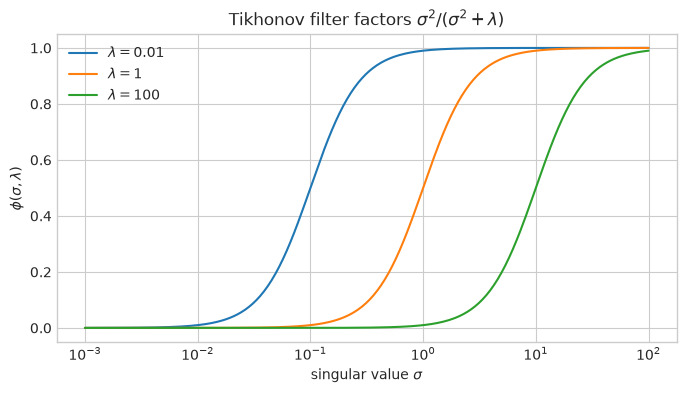

In [2]:
sig = np.logspace(-3, 2, 300)
fig, ax = plt.subplots(figsize=(8, 4))
for lam in (1e-2, 1, 1e2):
    ax.semilogx(sig, sig**2 / (sig**2 + lam), label=rf"$\lambda = {lam:g}$")
ax.set(xlabel=r"singular value $\sigma$", ylabel=r"$\phi(\sigma, \lambda)$", title=r"Tikhonov filter factors $\sigma^2/(\sigma^2+\lambda)$")
ax.legend()
plt.show()

### Decision guide

| Situation | Method |
|---|---|
| Small $n$, well conditioned | normal equations / `lstsq` |
| Rank-deficient or ill-conditioned | pseudo-inverse or ridge |
| Large $n$ or $m$, sparse | CG / gradient descent (minibatch SGD at scale) |
| Nonlinear model | gradient-based optimization |

Remember: prepend the bias column, scale the features for iterative methods, and never regularize $\theta_0$ in practice.